# Customer Churn Prediction

The goal of this project is to predict which telecom customers are likely to cancel their subscription. Identifying at-risk customers early gives the business a chance to intervene before losing them.

The dataset contains customer account and usage records. The target variable is `churn`, which indicates whether the customer left (yes/no).

The pipeline covers data cleaning, exploratory analysis, feature engineering, logistic regression, and model evaluation using AUC and cross-validation.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Data

Update the path below to match your local environment.

In [ ]:
df = pd.read_csv('../data/churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Cleaning

### 3.1 Standardize Column and String Values

Column names and string values are converted to lowercase with underscores so everything is consistent and easy to reference in code.

In [3]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
categorical_columns = list(df.select_dtypes(include=['object']).columns)
for col in categorical_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')

df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-vhveg,female,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,29.85,29.85,no
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one_year,no,mailed_check,56.95,1889.5,no
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed_check,53.85,108.15,yes
3,7795-cfocw,male,0,no,no,45,no,no_phone_service,dsl,yes,...,yes,yes,no,no,one_year,no,bank_transfer_(automatic),42.30,1840.75,no
4,9237-hqitu,female,0,no,no,2,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.70,151.65,yes


### 3.2 Convert `totalcharges` to Numeric

The `totalcharges` column is read as a string because some rows contain a blank space instead of a number. This happens for customers with zero tenure who have not been billed yet.

`pd.to_numeric(..., errors='coerce')` converts the column to float64 and turns the blank spaces into NaN. We then fill those NaN values with 0, since a new customer with no charges has effectively zero total charges.

Note: always assign the result back to the column. `.fillna(0)` returns a new object and does not modify the DataFrame in place.

In [4]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

### 3.3 Verify the Conversion

Confirm the dtype changed to float64 and no NaN values remain.

In [5]:
print('dtype     :', df.totalcharges.dtype)
print('NaN count :', df.totalcharges.isnull().sum())

dtype     : float64
NaN count : 0


### 3.4 Encode Target Variable

The `churn` column is converted from yes/no strings to binary integers. 1 means churned, 0 means stayed.

In [6]:
df.churn = (df.churn == 'yes').astype(int)
df.churn.value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

## 4. Train / Validation / Test Split

The data is split into three sets:

| Set | Purpose | Size |
|---|---|---|
| `df_train` | Train the model | 60% |
| `df_val` | Evaluate during development | 20% |
| `df_test` | Final unbiased evaluation | 20% |

We first split off 20% as the test set, then split the remaining 80% into 75/25 to get the 60/20 train/val proportions.

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
train, df_test = train_test_split(df, test_size=0.2, random_state=42)
len(train), len(df_test)

(5634, 1409)

In [9]:
df_train, df_val = train_test_split(train, test_size=0.25, random_state=42)
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

### 4.1 Separate Features from Target

The `churn` column is extracted into separate arrays before being deleted from the feature DataFrames. This is important to prevent data leakage, since the model should never see the target as an input.

In [10]:
y_train = df_train.churn.values
y_val   = df_val.churn.values
y_test  = df_test.churn.values

In [11]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

## 5. Exploratory Data Analysis (EDA)

EDA is done on `df_full_train`, a copy of the full 80% training pool that still has the `churn` column. We do not use `df_train` here because churn has already been removed from it. Keeping a separate `df_full_train` also avoids accidentally overwriting the prepared training set.

In [12]:
df_full_train = train.copy().reset_index(drop=True)
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,4223-bkeor,female,0,no,yes,21,yes,no,dsl,yes,...,yes,no,no,yes,one_year,no,mailed_check,64.85,1336.80,0
1,6035-riiom,female,0,no,no,54,yes,yes,fiber_optic,no,...,no,no,yes,yes,two_year,yes,bank_transfer_(automatic),97.20,5129.45,0
2,3797-vtidr,male,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,23.45,23.45,1
3,2568-brgyx,male,0,no,no,4,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.20,237.95,1
4,2775-sefee,male,0,no,yes,0,yes,yes,dsl,yes,...,no,yes,no,no,two_year,yes,bank_transfer_(automatic),61.90,0.00,0


### 5.1 Check for Missing Values

In [13]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

### 5.2 Churn Rate Distribution

What share of customers in the training data actually churned?

In [14]:
df_full_train.churn.value_counts(normalize=True)

churn
0    0.734469
1    0.265531
Name: proportion, dtype: float64

In [15]:
# global churn rate, used as the baseline for feature importance
round(df_full_train.churn.value_counts(normalize=True), 2)

churn
0    0.73
1    0.27
Name: proportion, dtype: float64

### 5.3 Feature Overview

In [16]:
df_full_train.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

In [17]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

### 5.4 Define Feature Lists

In [18]:
numerical   = ['tenure', 'monthlycharges', 'totalcharges']

categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
               'phoneservice', 'multiplelines', 'internetservice',
               'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
               'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
               'paymentmethod']

In [19]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

## 6. Feature Importance

Three methods are used to identify which features most influence churn:

| Method | What it measures |
|---|---|
| Churn rate | Average churn probability per category value |
| Risk ratio | How much more or less likely a group is to churn compared to the global average |
| Mutual information | Statistical dependency between a feature and the target |

### 6.1 Churn Rate Analysis

The global churn rate is the baseline. If a subgroup's rate is higher, it's a potential risk factor.

In [20]:
global_churn_rate = df_full_train.churn.mean()
global_churn_rate

np.float64(0.2655307064252751)

In [21]:
churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
churn_female

np.float64(0.2708409173643975)

In [22]:
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean()
churn_male

np.float64(0.26047800484932454)

In [23]:
df_full_train.partner.value_counts()

partner
no     2904
yes    2730
Name: count, dtype: int64

In [24]:
churn_partner     = df_full_train[df_full_train.partner == 'yes'].churn.mean()
churn_non_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()
churn_partner, churn_non_partner

(np.float64(0.20073260073260074), np.float64(0.32644628099173556))

Difference from the global rate. A positive value means higher-than-average churn risk.

In [25]:
global_churn_rate - churn_partner, global_churn_rate - churn_non_partner

(np.float64(0.06479810569267436), np.float64(-0.06091557456646046))

In [26]:
global_churn_rate - churn_male,    global_churn_rate - churn_female

(np.float64(0.005052701575950558), np.float64(-0.005310210939122428))

### 6.2 Risk Ratio

Risk ratio = group churn rate / global churn rate

- ratio > 1: group churns more than average
- ratio < 1: group churns less than average

In [27]:
churn_partner_ratio     = churn_partner     / global_churn_rate
churn_non_partner_ratio = churn_non_partner / global_churn_rate
churn_partner_ratio, churn_non_partner_ratio

(np.float64(0.7559675618499149), np.float64(1.2294106598311754))

### 6.3 Churn Rate and Risk Ratio for All Categorical Features

This is equivalent to running the following query for each categorical column:

```sql
SELECT
    gender,
    AVG(churn),
    AVG(churn) - global_churn_rate AS diff,
    AVG(churn) / global_churn_rate AS risk
FROM data
GROUP BY gender;
```

In [28]:
from IPython.display import display

In [29]:
for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count']).reset_index()
    df_group['diff'] = df_group['mean'] - global_churn_rate
    df_group['risk'] = df_group['mean'] / global_churn_rate
    display(df_group)
    print('-----------------------------')

gender


,gender,mean,count,diff,risk
0,female,0.270841,2747,0.005310,1.019998
1,male,0.260478,2887,-0.005053,0.980971


-----------------------------
seniorcitizen


,seniorcitizen,mean,count,diff,risk
0,0,0.237098,4728,-0.028433,0.892922
1,1,0.413907,906,0.148377,1.558793


-----------------------------
partner


...

-----------------------------
paperlessbilling


,paperlessbilling,mean,count,diff,risk
0,no,0.16414,2309,-0.101390,0.618159
1,yes,0.33594,3325,0.070409,1.265164


-----------------------------
paymentmethod


,paymentmethod,mean,count,diff,risk
0,bank_transfer_(automatic),0.174475,1238,-0.091056,0.657080
1,credit_card_(automatic),0.152404,1227,-0.113126,0.573961
2,electronic_check,0.449921,1887,0.184390,1.694420
3,mailed_check,0.190328,1282,-0.075203,0.716782


-----------------------------


## 7. Mutual Information

Mutual Information (MI) measures how much knowing a feature reduces uncertainty about the target. A high MI value means the feature carries useful signal for predicting churn. A low value means it is nearly independent of churn.

Unlike correlation, MI is non-linear and works directly on raw categorical values without requiring encoding.

In [30]:
from sklearn.metrics import mutual_info_score

In [31]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

df_full_train[categorical].apply(mutual_info_churn_score).sort_values(ascending=False)

contract            0.096652
onlinesecurity      0.063393
techsupport         0.060935
internetservice     0.053313
onlinebackup        0.045424
paymentmethod       0.042861
deviceprotection    0.042007
streamingtv         0.030844
streamingmovies     0.030705
paperlessbilling    0.019077
dependents          0.014129
partner             0.010227
seniorcitizen       0.010059
multiplelines       0.000654
gender              0.000069
phoneservice        0.000040
dtype: float64

## 8. Correlation Analysis

For numerical features, Pearson correlation gives a quick measure of linear association with churn.

- Values near +1: strong positive association
- Values near -1: strong negative association
- Values near 0: little linear relationship

In [32]:
df_full_train.tenure.max()

np.int64(72)

In [33]:
df_full_train[numerical].corrwith(df_full_train.churn).sort_values(ascending=False)

monthlycharges    0.188574
totalcharges     -0.193370
tenure           -0.344925
dtype: float64

## 9. Feature Engineering

Logistic Regression requires numeric input. `DictVectorizer` handles the conversion by turning each row into a dictionary and then one-hot encoding the categorical values.

The vectorizer is fit only on the training set and then applied to the validation set without re-fitting. Re-fitting on validation data would cause leakage.

In [34]:
from sklearn.feature_extraction import DictVectorizer

In [35]:
train_dicts = df_train[categorical + numerical].to_dict(orient='records')

In [36]:
dv      = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val     = dv.transform(val_dicts)

In [37]:
X_train.shape

(4225, 45)

## 10. Logistic Regression

Logistic Regression is used as the baseline model. It is fast to train, easy to interpret, and gives a good reference point before trying more complex approaches.

Hyperparameters:
- `solver='liblinear'`: works well for small to medium datasets
- `C=1.0`: inverse of regularization strength
- `max_iter=1000`: maximum solver iterations

In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

### 10.1 Model Parameters

The intercept is the baseline log-odds of churn when all features are zero. The coefficients show the weight assigned to each feature. Positive values push the prediction toward churn, negative values push it away.

In [40]:
model.intercept_[0]

np.float64(-0.14501434263511598)

In [41]:
model.coef_[0].round(3)

array([ 0.63 , -0.16 , -0.615, -0.054, -0.091,  0.027, -0.132, -0.04 ,
        0.015, -0.16 , -0.327,  0.314, -0.132,  0.003, -0.225,  0.124,
       -0.044,  0.076, -0.132, -0.089,  0.205, -0.132, -0.217, -0.241,
        0.096, -0.076, -0.069, -0.107, -0.186,  0.211, -0.064,  0.124,
       -0.269,  0.163, -0.139, -0.132,  0.126, -0.059, -0.132,  0.046,
        0.16 , -0.132, -0.173, -0.055,  0.   ])

### 10.2 Predictions on the Validation Set

`predict_proba()` returns the probability of each class. We take `[:, 1]` to get the churn probability per customer, then apply a threshold of 0.5 to produce binary predictions.

In [42]:
y_pred = model.predict_proba(X_val)[:, 1]

In [43]:
y_pred

array([0.16720217, 0.25313367, 0.43565892, ..., 0.71346592, 0.05055742,
       0.0360238 ], shape=(1409,))

In [44]:
churn_decision = (y_pred >= 0.5)

Customers predicted to churn:

In [45]:
df_val[churn_decision]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
3334,0337-cnpze,female,0,no,no,41,yes,yes,fiber_optic,no,yes,yes,no,yes,yes,month-to-month,yes,electronic_check,106.30,4443.45
2173,2038-oeqzh,male,0,no,no,4,yes,no,fiber_optic,no,no,yes,no,no,yes,month-to-month,no,electronic_check,86.05,308.10
5831,9846-gkxas,female,0,no,no,9,yes,no,fiber_optic,no,no,no,no,yes,yes,month-to-month,yes,bank_transfer_(automatic),90.80,809.75
2133,8051-hjrlt,female,1,no,no,1,yes,no,fiber_optic,no,no,no,no,no,no,month-to-month,yes,electronic_check,70.55,70.55
5479,8990-zxlsu,female,0,no,no,9,yes,no,fiber_optic,no,no,no,no,no,no,month-to-month,no,electronic_check,69.05,651.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6440,2809-zmyoq,female,0,no,no,32,yes,yes,fiber_optic,no,no,yes,no,yes,yes,month-to-month,yes,electronic_check,101.35,3334.90
1821,3536-iqctx,male,1,yes,no,32,yes,yes,fiber_optic,no,no,no,no,no,yes,month-to-month,no,electronic_check,85.30,2661.10
5706,5196-sgoak,female,0,no,no,1,yes,no,fiber_optic,no,yes,no,no,no,no,month-to-month,yes,electronic_check,75.70,75.70
875,3050-gbush,female,0,no,no,3,no,no_phone_service,dsl,no,no,no,no,yes,no,month-to-month,yes,credit_card_(automatic),34.80,113.95


A comparison table of predicted vs actual values. The `correct` column is 1 where the prediction matches the actual label.

In [46]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction']  = churn_decision.astype(int)
df_pred['actual']      = y_val
df_pred['correct']     = (df_pred['prediction'] == df_pred['actual']).astype(int)

df_pred.head(10)

,probability,prediction,actual,correct
0,0.167202,0,0,1
1,0.253134,0,0,1
2,0.435659,0,1,0
3,0.562367,1,1,1
4,0.049741,0,0,1
5,0.125869,0,0,1
6,0.377992,0,0,1
7,0.013390,0,0,1
8,0.063903,0,0,1
9,0.147765,0,0,1


Overall accuracy on the validation set:

In [47]:
df_pred['correct'].mean()

np.float64(0.8034066713981547)

### 10.3 Retrain on Full Training Data

The initial model was trained on `df_train` (60%) as a quick check. We now retrain on `df_full_train` (80%) before evaluating. More training data generally improves generalization.

The vectorizer is also re-fit on `df_full_train` so its vocabulary reflects the full training distribution.

In [48]:
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient='records')

In [49]:
dv           = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

In [50]:
y_full_train = df_full_train.churn.values

In [51]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_full_train, y_full_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [52]:
dicts_val = df_val[categorical + numerical].to_dict(orient='records')

In [53]:
X_val = dv.transform(dicts_val)

In [54]:
y_pred = model.predict_proba(X_val)[:, 1]

In [55]:
churn_decision = (y_pred > 0.5).astype(int)

Accuracy of the retrained model on the validation set:

In [56]:
(y_val == churn_decision).mean()

np.float64(0.8041163946061036)

In [57]:
len(y_val)

1409

## 11. Evaluation

Accuracy on its own does not tell the full story, especially when the classes are imbalanced. We look at accuracy across thresholds, the confusion matrix, precision, recall, and the ROC curve.

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### 11.1 Accuracy Across Thresholds

The 0.5 threshold is arbitrary. Sweeping from 0 to 1 shows how accuracy changes and whether a different cutoff would work better.

In [59]:
accuracy_score(y_val, churn_decision)

0.8041163946061036

threshold: 0.00, accuracy: 0.269
threshold: 0.05, accuracy: 0.522
threshold: 0.10, accuracy: 0.617
threshold: 0.15, accuracy: 0.671
threshold: 0.20, accuracy: 0.704
threshold: 0.25, accuracy: 0.744
threshold: 0.30, accuracy: 0.770
threshold: 0.35, accuracy: 0.778
threshold: 0.40, accuracy: 0.789
threshold: 0.45, accuracy: 0.796
threshold: 0.50, accuracy: 0.804
threshold: 0.55, accuracy: 0.803
threshold: 0.60, accuracy: 0.784
threshold: 0.65, accuracy: 0.782
threshold: 0.70, accuracy: 0.765
threshold: 0.75, accuracy: 0.745
threshold: 0.80, accuracy: 0.736
threshold: 0.85, accuracy: 0.731
threshold: 0.90, accuracy: 0.731
threshold: 0.95, accuracy: 0.731
threshold: 1.00, accuracy: 0.731


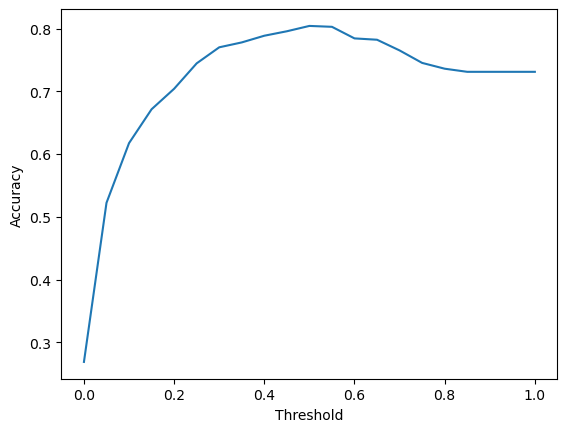

In [60]:
thresholds = np.linspace(0, 1, 21)
scores = []
for t in thresholds:
    score = accuracy_score(y_val, y_pred >= t)
    print(f'threshold: {t:.2f}, accuracy: {score:.3f}')
    scores.append(score)

plt.plot(thresholds, scores)
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.show()

### 11.2 Confusion Matrix

A confusion matrix breaks predictions into four categories:

| | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

- TP: correctly predicted churners
- TN: correctly predicted non-churners
- FP: predicted churn but customer stayed (false alarm)
- FN: predicted no churn but customer left (missed churner)

In churn prediction, FN is usually the costlier error since a missed churner is a lost customer.

In [61]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

In [62]:
t = 0.5
predicted_positive = (y_pred >= t)
predicted_negative = (y_pred < t)

In [63]:
predicted_positive[:5]

array([False, False, False,  True, False])

In [64]:
actual_positive[:5]

array([False, False,  True,  True, False])

In [65]:
tp = (predicted_positive & actual_positive).sum()
tn = (predicted_negative & actual_negative).sum()
fp = (predicted_positive & actual_negative).sum()
fn = (predicted_negative & actual_positive).sum()
tp, fp, fn, tn

(np.int64(205), np.int64(102), np.int64(174), np.int64(928))

In [66]:
confusion_matrix = np.array([[tn, fp],
                             [fn, tp]])
confusion_matrix

array([[928, 102],
       [174, 205]])

### 11.3 Precision and Recall

**Precision** = TP / (TP + FP). Of all customers flagged as churners, what fraction actually churned? High precision means fewer false alarms.

**Recall** = TP / (TP + FN). Of all actual churners, what fraction did we catch? High recall means fewer missed churners.

Raising the threshold increases precision but reduces recall, and vice versa.

In [67]:
precision = tp / (tp + fp)
precision

np.float64(0.6677524429967426)

In [68]:
recall = tp / (tp + fn)
recall

np.float64(0.5408970976253298)

### 11.4 ROC Curve

The ROC curve plots TPR against FPR at every possible threshold.

- TPR (Recall) = TP / (TP + FN): how many actual churners we catch
- FPR = FP / (FP + TN): how many non-churners we wrongly flag

The values below are computed at a single threshold of 0.5. The loop after computes them across all thresholds to build the full curve.

In [69]:
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
print(f'TPR: {tpr:.3f}, FPR: {fpr:.3f}')

TPR: 0.541, FPR: 0.099


In [70]:
scores_roc = []
thresholds = np.linspace(0, 1, 21)
for t in thresholds:
    actual_positive    = (y_val == 1)
    actual_negative    = (y_val == 0)
    predicted_positive = (y_pred >= t)
    predicted_negative = (y_pred < t)

    tp = (predicted_positive & actual_positive).sum()
    tn = (predicted_negative & actual_negative).sum()
    fp = (predicted_positive & actual_negative).sum()
    fn = (predicted_negative & actual_positive).sum()

    scores_roc.append((t, tp, fp, fn, tn))

df_roc_scores = pd.DataFrame(scores_roc, columns=['threshold', 'tp', 'fp', 'fn', 'tn'])
df_roc_scores.head()

,threshold,tp,fp,fn,tn
0,0.00,379,1030,0,0
1,0.05,369,663,10,367
2,0.10,358,518,21,512
3,0.15,348,432,31,598
4,0.20,321,359,58,671


In [71]:
df_roc_scores['tpr'] = df_roc_scores['tp'] / (df_roc_scores['tp'] + df_roc_scores['fn'])
df_roc_scores['fpr'] = df_roc_scores['fp'] / (df_roc_scores['fp'] + df_roc_scores['tn'])
df_roc_scores.head()

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.00,379,1030,0,0,1.000000,1.000000
1,0.05,369,663,10,367,0.973615,0.643689
2,0.10,358,518,21,512,0.944591,0.502913
3,0.15,348,432,31,598,0.918206,0.419417
4,0.20,321,359,58,671,0.846966,0.348544


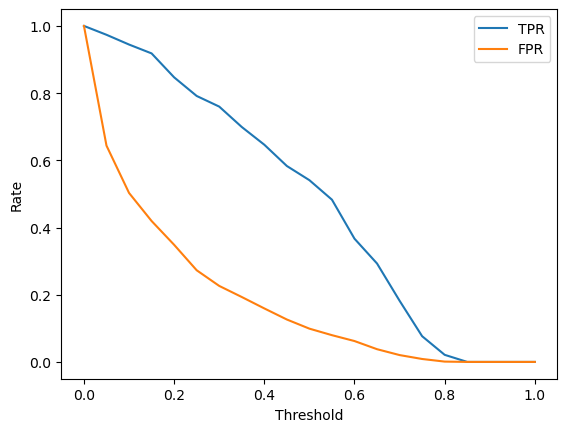

In [72]:
plt.plot(df_roc_scores.threshold, df_roc_scores.tpr, label='TPR')
plt.plot(df_roc_scores.threshold, df_roc_scores.fpr, label='FPR')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.legend()
plt.show()

### 11.5 Random Model Baseline

A model that scores customers randomly serves as the lower bound for comparison. Its TPR and FPR should be roughly equal at any threshold since it carries no real signal.

In [73]:
np.random.seed(42)
y_rand = np.random.uniform(0, 1, size=len(y_val))
((y_rand >= 0.5) == y_val).mean()

np.float64(0.49893541518807666)

The TPR/FPR calculation is wrapped in a reusable function to avoid repeating the loop for each model variant.

In [74]:
def tpr_fpr_dataframe(y_val, y_pred):
    thresholds = np.linspace(0, 1, 21)
    scores_roc = []
    for t in thresholds:
        actual_positive    = (y_val == 1)
        actual_negative    = (y_val == 0)
        predicted_positive = (y_pred >= t)
        predicted_negative = (y_pred < t)

        tp = (predicted_positive & actual_positive).sum()
        tn = (predicted_negative & actual_negative).sum()
        fp = (predicted_positive & actual_negative).sum()
        fn = (predicted_negative & actual_positive).sum()

        scores_roc.append((t, tp, fp, fn, tn))

    df_scores = pd.DataFrame(scores_roc, columns=['threshold', 'tp', 'fp', 'fn', 'tn'])
    df_scores['tpr'] = df_scores['tp'] / (df_scores['tp'] + df_scores['fn'])
    df_scores['fpr'] = df_scores['fp'] / (df_scores['fp'] + df_scores['tn'])
    return df_scores

In [75]:
df_rand = tpr_fpr_dataframe(y_val, y_rand)
df_rand.head(5)

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.00,379,1030,0,0,1.000000,1.000000
1,0.05,351,982,28,48,0.926121,0.953398
2,0.10,335,923,44,107,0.883905,0.896117
3,0.15,310,874,69,156,0.817942,0.848544
4,0.20,290,813,89,217,0.765172,0.789320


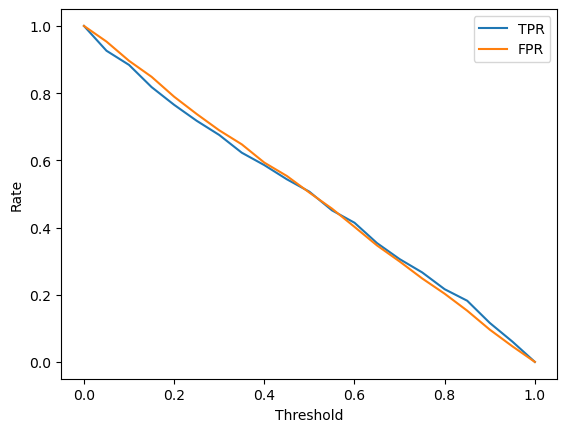

In [76]:
plt.plot(df_rand.threshold, df_rand.tpr, label='TPR')
plt.plot(df_rand.threshold, df_rand.fpr, label='FPR')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.legend()
plt.show()

### 11.6 Ideal Model

An ideal model ranks every actual churner above every non-churner. TPR rises immediately to 1 while FPR stays at 0 until all positives are captured.

To simulate this, all negatives are placed first and all positives last, then linearly spaced scores from 0 to 1 are assigned. The separating threshold is `1 - y_val.mean()`, which equals the fraction of non-churners. That is the point where the predicted scores transition from the negative group into the positive group.

In [77]:
num_negative = (y_val == 0).sum()
num_positive = (y_val == 1).sum()
num_negative, num_positive

(np.int64(1030), np.int64(379))

In [78]:
y_ideal      = np.repeat([0, 1], [num_negative, num_positive])
y_ideal_pred = np.linspace(0, 1, len(y_val))

In [79]:
1 - y_val.mean()  # separating threshold for the ideal model

np.float64(0.7310149041873669)

In [80]:
((y_ideal_pred >= 0.731) == y_ideal).mean()

np.float64(1.0)

In [81]:
df_ideal = tpr_fpr_dataframe(y_ideal, y_ideal_pred)
df_ideal.head(5)

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.00,379,1030,0,0,1.0,1.000000
1,0.05,379,959,0,71,1.0,0.931068
2,0.10,379,889,0,141,1.0,0.863107
3,0.15,379,818,0,212,1.0,0.794175
4,0.20,379,748,0,282,1.0,0.726214


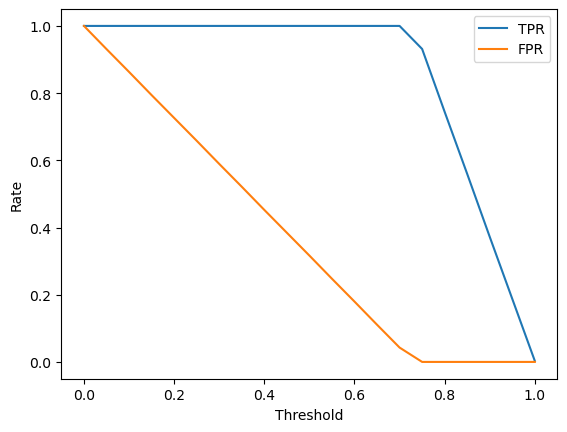

In [82]:
plt.plot(df_ideal.threshold, df_ideal.tpr, label='TPR')
plt.plot(df_ideal.threshold, df_ideal.fpr, label='FPR')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.legend()
plt.show()

### 11.7 Model vs Random vs Ideal

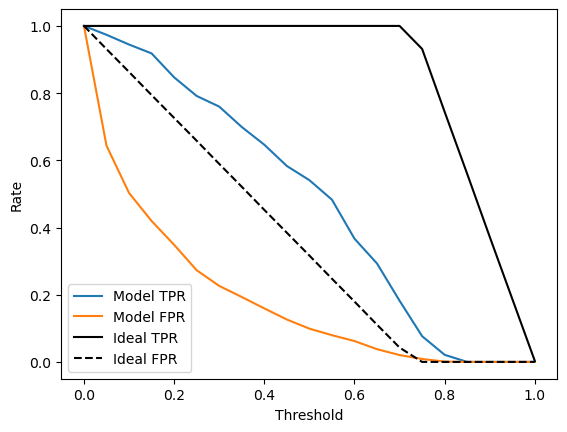

In [83]:
plt.plot(df_roc_scores.threshold, df_roc_scores.tpr, label='Model TPR')
plt.plot(df_roc_scores.threshold, df_roc_scores.fpr, label='Model FPR')
plt.plot(df_ideal.threshold, df_ideal.tpr, label='Ideal TPR', color='black')
plt.plot(df_ideal.threshold, df_ideal.fpr, label='Ideal FPR', color='black', linestyle='--')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.legend()
plt.show()

### 11.8 ROC Space

The ROC curve plots FPR on the x-axis against TPR on the y-axis. Each point on the curve corresponds to one threshold setting. A model closer to the top-left corner performs better. The diagonal represents a random model with no discriminating power.

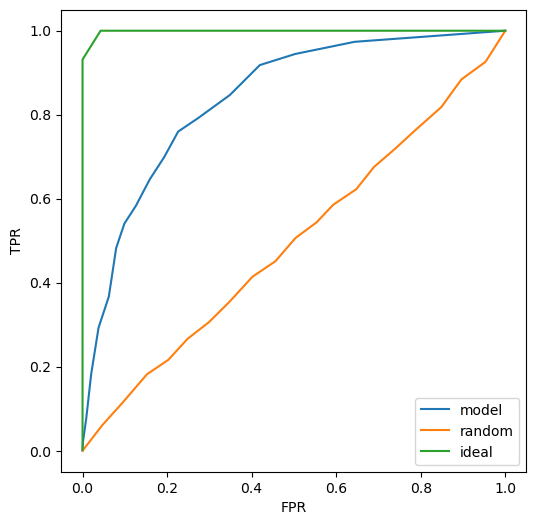

In [84]:
plt.figure(figsize=(6, 6))
plt.plot(df_roc_scores.fpr, df_roc_scores.tpr, label='model')
plt.plot(df_rand.fpr,       df_rand.tpr,        label='random')
plt.plot(df_ideal.fpr,      df_ideal.tpr,        label='ideal')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

## 12. AUC-ROC

AUC summarizes the ROC curve as a single number. It represents the probability that the model ranks a random positive example above a random negative one.

- AUC = 1.0: perfect ranking
- AUC = 0.5: no better than random
- AUC = 0.7: correct ranking 70% of the time

AUC is useful for imbalanced datasets because it is threshold-independent.

In [85]:
from sklearn.metrics import auc, roc_auc_score

In [86]:
auc(df_roc_scores.fpr, df_roc_scores.tpr)

np.float64(0.8390706253041986)

In [87]:
auc(df_ideal.fpr, df_ideal.tpr)

np.float64(0.9985347234674795)

In [88]:
roc_auc_score(y_val, y_pred)

np.float64(0.8432563977764683)

## 13. Cross-Validation

A single train/val split can give misleading results depending on which samples happened to land in each set. K-Fold cross-validation addresses this by training and evaluating the model k times, each time using a different fold as the validation set.

The mean AUC across folds gives a more reliable performance estimate. The standard deviation shows how stable that performance is.

The training and prediction steps are first wrapped in functions to keep the loop clean.

In [89]:
def train(df_train, y_train):
    dicts   = df_train[categorical + numerical].to_dict(orient='records')
    dv      = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train, y_train)

    return dv, model

In [90]:
dv, model = train(df_train, y_train)

In [91]:
def predict(df, dv, model):
    dicts  = df[categorical + numerical].to_dict(orient='records')
    X      = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]
    return y_pred

In [92]:
y_pred = predict(df_val, dv, model)

In [93]:
from sklearn.model_selection import KFold

In [94]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

Each fold: split `df_full_train` into a training and validation portion, train a fresh model, compute AUC on the validation portion.

In [95]:
scores_kfold = []
for train_idx, val_idx in kfold.split(df_full_train):
    df_train_fold = df_full_train.iloc[train_idx]
    df_val_fold   = df_full_train.iloc[val_idx]

    y_train_fold = df_train_fold.churn.values
    y_val_fold   = df_val_fold.churn.values

    dv, model   = train(df_train_fold, y_train_fold)
    y_pred_fold = predict(df_val_fold, dv, model)

    auc_score = roc_auc_score(y_val_fold, y_pred_fold)
    scores_kfold.append(auc_score)

In [96]:
scores_kfold

[np.float64(0.8345746877049247),
 np.float64(0.8444060904104407),
 np.float64(0.8384486949689395),
 np.float64(0.8477129885447465),
 np.float64(0.8352933977849843)]

In [97]:
print(f'Mean AUC: {np.mean(scores_kfold):.3f}')
print(f'Std  AUC: {np.std(scores_kfold):.3f}')

Mean AUC: 0.840
Std  AUC: 0.005


## 14. Final Evaluation on Test Set

Cross-validation gave a stable AUC estimate. The final step is to train on the full `df_full_train` set and evaluate once on `df_test`, data the model has not seen in any form. This is the unbiased estimate of production performance.

In [98]:
dv, model = train(df_full_train, df_full_train.churn.values)
y_pred    = predict(df_test, dv, model)

test_auc  = roc_auc_score(y_test, y_pred)
print(f'Test AUC: {test_auc:.3f}')

Test AUC: 0.861


### Saving the model



In [99]:
import pickle

In [100]:
output_file = 'model.bin'
with open(output_file, 'wb') as f_out:
    pickle.dump((dv, model), f_out)
    
output_file  

'model.bin'

#### Loading the saved model

In [101]:
import pickle

In [102]:
model_file = 'model.bin'
with open(model_file, 'rb') as f_in:
    dv, model = pickle.load(f_in)


In [103]:
dv, model

(DictVectorizer(sparse=False),
 LogisticRegression(max_iter=1000, solver='liblinear'))